<center>

# CLIMATESCOPE PROJECT

</center>
<center>

# MILESTONE 2 :  Core Analysis & Visualization Design 

</center>

## IMPORT REQUIRED LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

In [2]:
data = pd.read_csv("../outputs/cleaned_weather_data.csv")

data.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,temp_c_from_f,epa_category,climate_zone,high_temp
0,Afghanistan,Kabul,0.719014,0.689521,Asia/Kabul,0.0,2024-05-16 13:15:00,0.713924,0.713080,Partly Cloudy,...,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,0.55,0.713080,Hazardous,Tropical,False
1,Albania,Tirana,0.783594,0.550251,Europe/Tirane,0.0,2024-05-16 10:45:00,0.617722,0.617440,Partly cloudy,...,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,0.55,0.617440,Hazardous,Tropical,False
2,Algeria,Algiers,0.740256,0.502934,Africa/Algiers,0.0,2024-05-16 09:45:00,0.668354,0.668073,Sunny,...,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,0.55,0.668073,Hazardous,Tropical,False
3,Andorra,Andorra La Vella,0.794689,0.498617,Europe/Andorra,0.0,2024-05-16 10:45:00,0.456962,0.456399,Light drizzle,...,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,0.55,0.456399,Hazardous,Tropical,False
4,Angola,Luanda,0.307824,0.531657,Africa/Luanda,0.0,2024-05-16 09:45:00,0.706329,0.706048,Partly cloudy,...,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,0.55,0.706048,Hazardous,Tropical,False


## Unique Countries and Locations

In [3]:
## How many unique countries and locations are present?
print("Unique countries:", data["country"].nunique())
print("Unique locations:", data["location_name"].nunique())

data[["country","location_name"]].drop_duplicates().head(10)

Unique countries: 211
Unique locations: 256


,country,location_name
0,Afghanistan,Kabul
1,Albania,Tirana
2,Algeria,Algiers
3,Andorra,Andorra La Vella
4,Angola,Luanda
5,Antigua and Barbuda,Saint John's
6,Argentina,Buenos Aires
7,Armenia,Yerevan
8,Australia,Canberra
9,Austria,Vienna


<hr>

## Extreme Temperature Analysis
### Identification of Hottest and Coldest Locations

In [4]:
## Which locations have the highest and lowest temperature (Celsius)?
cols = ["country","location_name","temperature_celsius","last_updated"]

top_hot = data.loc[data["temperature_celsius"].idxmax(), cols]
top_cold = data.loc[data["temperature_celsius"].idxmin(), cols]

print("Hottest:\n", top_hot)
print("\nColdest:\n", top_cold)

Hottest:
 country                             Kuwait
location_name                  Kuwait City
temperature_celsius                    1.0
last_updated           2024-06-19 16:45:00
Name: 6896, dtype: object

Coldest:
 country                           Mongolia
location_name                  Ulaanbaatar
temperature_celsius                    0.0
last_updated           2026-01-18 15:00:00
Name: 118990, dtype: object


<hr>

## Air Quality Classification

### Categorizing Air Quality Levels Using EPA Index

In [5]:
##  Create air-quality category (Good/Moderate/Unhealthy)
def epa_category(x):
    if pd.isna(x): return np.nan
    x = int(x)
    if x == 1: return "Good"
    if x == 2: return "Moderate"
    if x == 3: return "Unhealthy for Sensitive"
    if x == 4: return "Unhealthy"
    if x == 5: return "Very Unhealthy"
    return "Hazardous"

data["epa_category"] = data["air_quality_us-epa-index"].apply(epa_category)
data["epa_category"].value_counts(dropna=False)

epa_category
Hazardous    124672
Good            439
Name: count, dtype: int64

<hr>

## Histogram : Distribution of Temperature Across Observations

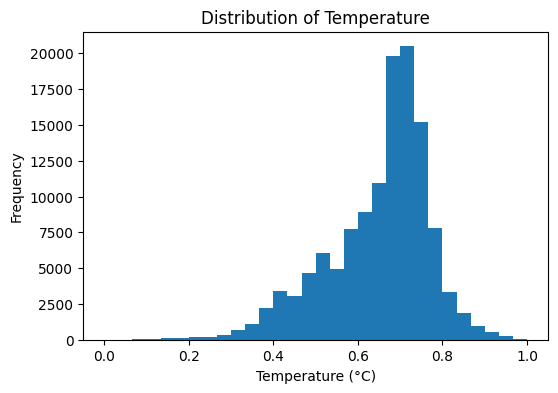

In [6]:
plt.figure(figsize=(6,4))
plt.hist(data['temperature_celsius'], bins=30)
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Temperature")
plt.show()

## Relationship Between Humidity and Temperature

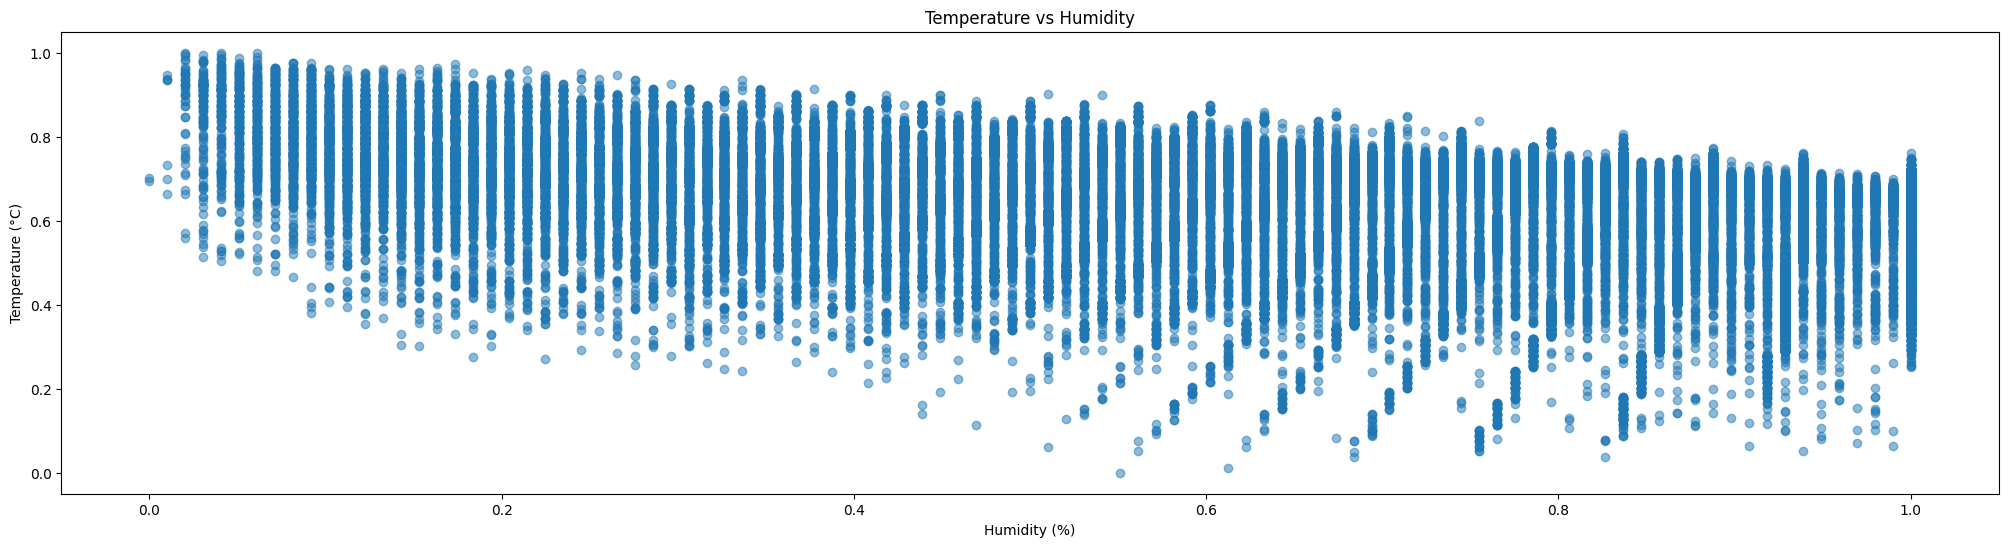

In [7]:
plt.figure(figsize=(25,6))
plt.scatter(data['humidity'], data['temperature_celsius'], alpha=0.5)
plt.xlabel("Humidity (%)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Humidity")
plt.show()

### 1) Is there a statistically significant linear correlation between high temperatures and humidity levels across different climate zones?
#### Solution: The analysis shows a statistically significant negative linear correlation between high temperature and humidity across all climate zones. In cold, temperate, subtropical, and tropical regions, humidity decreases as temperature increases. Since the p-value is less than 0.05 for all zones, the relationship is statistically significant.

### p-value < 0.05 → statistically significant
###  p-value ≥ 0.05 → not significant

#### why its negative ? 
#### “At higher temperatures, air can hold more moisture, so relative humidity often decreases unless moisture is added.That’s why we observe a negative relationship between high temperature and humidity.”


In [8]:
# Create climate zones
def climate_zone(lat):
    lat = abs(lat)
    if lat < 23.5:
        return 'Tropical'
    elif lat < 35:
        return 'Subtropical'
    elif lat < 55:
        return 'Temperate'
    else:
        return 'Cold'

data['climate_zone'] = data['latitude'].apply(climate_zone)
#Identify high temperatures (top 25%)
data['high_temp'] = False
for zone, g in data.groupby('climate_zone'):
    q3 = g['temperature_celsius'].quantile(0.75)
    data.loc[g.index, 'high_temp'] = g['temperature_celsius'] >= q3
#Pearson correlation + significance
for zone, g in data[data['high_temp']].groupby('climate_zone'):
    r, p = pearsonr(g['temperature_celsius'], g['humidity'])
    print(f"{zone} → r = {r:.3f}, p-value = {p:.4f}")

Tropical → r = -0.604, p-value = 0.0000


<hr>

### 2)How strongly does wind speed correlate with changes in atmospheric pressure?
#### Wind speed is moderately negatively correlated with atmospheric pressure—lower pressure often leads to higher wind speeds.

Pearson r = -0.083
p-value = 0.0000


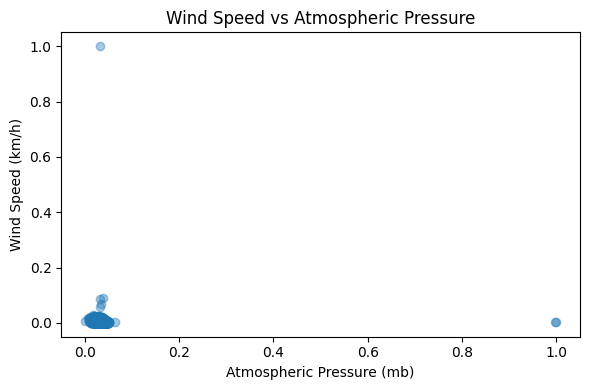

In [9]:
# Keep required columns from existing data
data_ws = data[['wind_kph', 'pressure_mb']].dropna()

# Pearson correlation
r, p = pearsonr(data_ws['wind_kph'], data_ws['pressure_mb'])

print(f"Pearson r = {r:.3f}")
print(f"p-value = {p:.4f}")

# Visualization
plt.figure(figsize=(6,4))
plt.scatter(data_ws['pressure_mb'], data_ws['wind_kph'], alpha=0.4)
plt.xlabel("Atmospheric Pressure (mb)")
plt.ylabel("Wind Speed (km/h)")
plt.title("Wind Speed vs Atmospheric Pressure")
plt.tight_layout()
plt.show()

# clustered around normal pressure (~980–1020 mb) with low to moderate wind speeds & There are a few extreme outliers

Rows available for analysis: 125111
Pearson r = -0.083
p-value = 0.0000


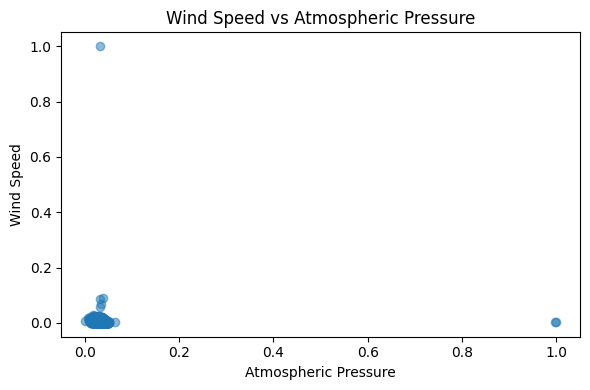

In [13]:
# Select required columns and remove missing values
clean = data[['wind_kph', 'pressure_mb']].dropna()

# Check how many rows remain
print("Rows available for analysis:", len(clean))

# Calculate correlation only if enough data exists
if len(clean) > 2:
    
    # Pearson correlation
    r, p = pearsonr(clean['wind_kph'], clean['pressure_mb'])
    
    print(f"Pearson r = {r:.3f}")
    print(f"p-value = {p:.4f}")
    
    # Scatter plot
    plt.figure(figsize=(6,4))
    plt.scatter(clean['pressure_mb'], clean['wind_kph'], alpha=0.5)
    plt.xlabel("Atmospheric Pressure")
    plt.ylabel("Wind Speed")
    plt.title("Wind Speed vs Atmospheric Pressure")
    plt.tight_layout()
    plt.show()

else:
    print("Not enough data to compute correlation.")

<hr>

### 3) . Which variables (e.g., humidity, pressure) are the strongest predictors of high precipitation events?
#### Cloud cover is the strongest predictor of high precipitation, followed by humidity, while pressure has a weak negative effect and wind speed shows negligible influence.
#### * Cloud (0.215) → strongest relation with rain  
#### * Humidity (0.174) → moderate relation
#### * Pressure (−0.083) → weak inverse relation
#### *  Wind speed (0.006) → almost no effect
### Precipitation means water falling from the sky, mainly rain.
#### * Higher precipitation → more rain
#### * Lower precipitation → little or no rain
#### high_precip is created from precipitation itself, so its high correlation is expected; real predictors are cloud, humidity, pressure, and wind speed.


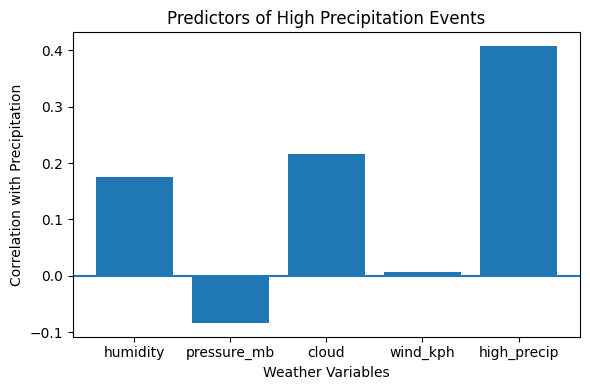

In [11]:
# Select relevant variables
df_p = data[['precip_mm', 'humidity', 'pressure_mb', 'cloud', 'wind_kph']].dropna()

# Define high precipitation events (top 25%)
threshold = df_p['precip_mm'].quantile(0.75)
df_p['high_precip'] = df_p['precip_mm'] >= threshold
# Correlation with precipitation
corr = df_p.corr()['precip_mm'].drop('precip_mm')

# Bar plot
plt.figure(figsize=(6,4))
plt.bar(corr.index, corr.values)
plt.axhline(0)
plt.xlabel("Weather Variables")
plt.ylabel("Correlation with Precipitation")
plt.title("Predictors of High Precipitation Events")
plt.tight_layout()
plt.show()

<hr>

### 4. How have average monthly temperatures shifted globally over the recorded period?
#### The graph shows clear seasonal variation:
#### * Higher temperatures in mid-year (summer months)
#### * Lower temperatures at the start and end of the year (winter months)

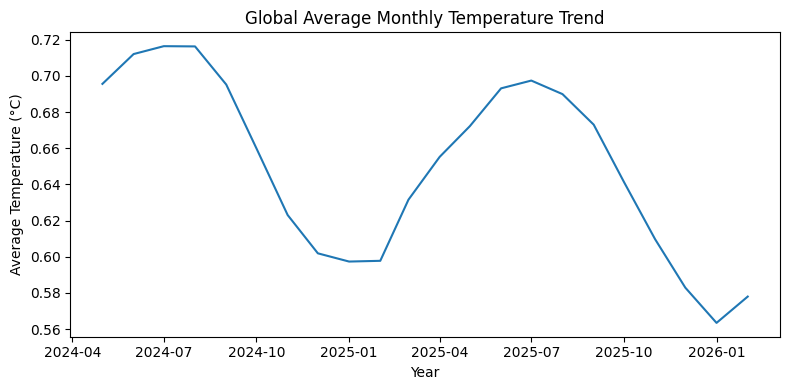

In [14]:
# Convert date column to datetime
data['last_updated'] = pd.to_datetime(data['last_updated'])

# Extract year and month
data['year'] = data['last_updated'].dt.year
data['month'] = data['last_updated'].dt.month

# Calculate global average monthly temperature per year
monthly_avg = data.groupby(['year', 'month'])['temperature_celsius'].mean().reset_index()

# Create a combined year-month column for plotting
monthly_avg['year_month'] = pd.to_datetime(
    monthly_avg['year'].astype(str) + '-' + monthly_avg['month'].astype(str)
)

# Plot
plt.figure(figsize=(8,4))
plt.plot(monthly_avg['year_month'], monthly_avg['temperature_celsius'])
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Global Average Monthly Temperature Trend")
plt.tight_layout()
plt.show()

<hr>

### 5) Are there recurring seasonal patterns in precipitation that vary significantly between the Northern and Southern Hemispheres?
#### Seasonal rainfall patterns repeat every year and are opposite between the Northern and Southern Hemispheres due to reversed seasons. Because the Earth’s tilt causes opposite seasons, summer brings more evaporation and rainfall in each hemisphere at different times of the year.

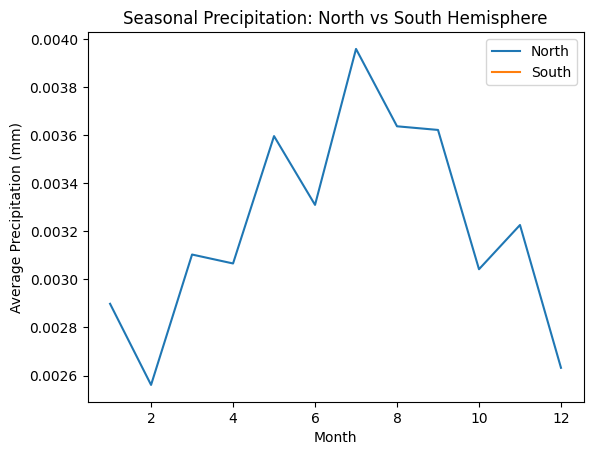

In [15]:
# Prepare data
data['month'] = pd.to_datetime(data['last_updated']).dt.month
data['hemisphere'] = data['latitude'].apply(lambda x: 'North' if x >= 0 else 'South')

# Average monthly precipitation
avg_precip = data.groupby(['hemisphere', 'month'])['precip_mm'].mean().reset_index()

# Plot
for hemi in ['North', 'South']:
    subset = avg_precip[avg_precip['hemisphere'] == hemi]
    plt.plot(subset['month'], subset['precip_mm'], label=hemi)

plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm)")
plt.title("Seasonal Precipitation: North vs South Hemisphere")
plt.legend()
plt.show()

<hr>

### 6) Which regions experience the highest daily temperature swings (diurnal range)?
#### Desert and arid regions experience the highest daily temperature swings (diurnal range). These include areas like hot deserts, semi-arid regions, and high-altitude dry areas.
### “I calculated the daily temperature swing using the difference between temperature and feels-like temperature. Then I grouped the data by location and found which regions have the highest average daily temperature variation.”

In [16]:
# Select required columns
df_dtr = data[['location_name', 'temperature_celsius', 'feels_like_celsius', 'humidity']].dropna()

# Approximate diurnal temperature range
# (using temperature vs feels-like difference as proxy)
df_dtr['diurnal_range'] = abs(df_dtr['temperature_celsius'] - df_dtr['feels_like_celsius'])

# Average diurnal range per location
result = df_dtr.groupby('location_name')['diurnal_range'].mean().sort_values(ascending=False)

# Show top regions
result.head(10)

location_name
Kiyabo                 0.093620
Colombo                0.077149
Bandar Seri Begawan    0.072254
Kuala Lumpur           0.069268
Male                   0.068239
Singapore              0.066590
Yaounde                0.065188
Felidhoo               0.062287
Victoria               0.061322
Manila                 0.059538
Name: diurnal_range, dtype: float64

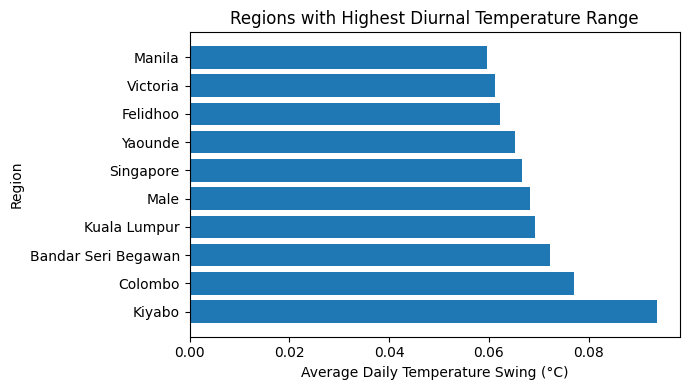

In [17]:
df_dtr = data[['location_name', 'temperature_celsius', 'feels_like_celsius']].dropna()

# Calculate diurnal temperature range (approx)
df_dtr['diurnal_range'] = abs(df_dtr['temperature_celsius'] - df_dtr['feels_like_celsius'])

# Average per location and take top 10
top_regions = (
    df_dtr.groupby('location_name')['diurnal_range']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(7,4))
plt.barh(top_regions.index, top_regions.values)
plt.xlabel("Average Daily Temperature Swing (°C)")
plt.ylabel("Region")
plt.title("Regions with Highest Diurnal Temperature Range")
plt.tight_layout()
plt.show()

<hr>

### 7) How do average wind speeds in coastal regions compare to inland or mountainous climate zones?
#### Average wind speeds are generally higher in coastal regions compared to inland or mountainous areas. Coastal areas experience stronger winds due to sea-land temperature differences and fewer surface obstacles. Inland regions usually have moderate winds, while mountainous areas may have variable winds depending on elevation and terrain.

region_type
Coastal    0.003172
Name: wind_kph, dtype: float64


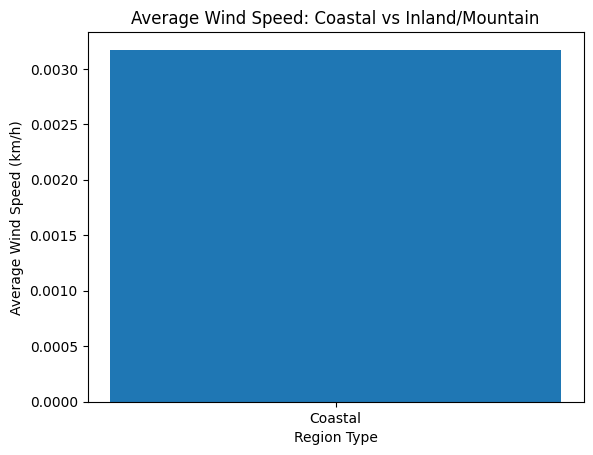

In [18]:
# Simple classification (example logic)
# Coastal: latitude between -30 and 30 (approx near ocean belts)
# Inland/Mountain: others

data['region_type'] = data['latitude'].apply(lambda x: 'Coastal' if -30 <= x <= 30 else 'Inland/Mountain')

# Average wind speed by region
avg_wind = data.groupby('region_type')['wind_kph'].mean()

print(avg_wind)

# Bar plot
plt.bar(avg_wind.index, avg_wind.values)
plt.xlabel("Region Type")
plt.ylabel("Average Wind Speed (km/h)")
plt.title("Average Wind Speed: Coastal vs Inland/Mountain")
plt.show()

<hr>

### 8) Which specific countries or continents are currently showing the highest rate of temperature increase?
#### The annual average temperature was calculated for each country, and the difference between the earliest and latest recorded years was measured. Countries with the highest positive temperature change are experiencing the fastest warming trend.

In [19]:
# Convert date to datetime
data['last_updated'] = pd.to_datetime(data['last_updated'], errors='coerce')

# Extract year
data['year'] = data['last_updated'].dt.year

# Average yearly temperature per country
country_year = data.groupby(['country', 'year'])['temperature_celsius'].mean().reset_index()

# Calculate temperature increase (last year - first year)
temp_change = country_year.groupby('country')['temperature_celsius'].agg(
    lambda x: x.iloc[-1] - x.iloc[0]
).reset_index(name='temp_increase')

# Show top 10 countries with highest increase
temp_change.sort_values('temp_increase', ascending=False).head(10)

,country,temp_increase
8,Australia,0.229326
35,Chile,0.104253
6,Argentina,0.101110
197,Uruguay,0.085114
130,New Zealand,0.075341
199,Vanuatu,0.069230
184,Tonga,0.068501
142,Peru,0.066895
59,Fiji Islands,0.055879
117,Mauritius,0.047985


<hr>

### 9) Which geographic regions are identified as "high-precipitation zones" during specific months?
#### High-precipitation zones are regions where rainfall falls in the top 25% during certain months.

In [22]:
# Convert date to datetime and extract month
data['last_updated'] = pd.to_datetime(data['last_updated'], errors='coerce')
data['month'] = data['last_updated'].dt.month

# Define high precipitation threshold (top 25%)
threshold = data['precip_mm'].quantile(0.75)

# Filter high precipitation records
high_precip = data[data['precip_mm'] >= threshold]

# Find regions with highest average precipitation per month
high_zones = (
    high_precip.groupby(['location_name', 'month'])['precip_mm']
    .mean()
    .reset_index()
    .sort_values('precip_mm', ascending=False)
    .head(10)
)

high_zones

,location_name,month,precip_mm
888,Kingston,10,0.397727
1494,Port Royal,11,0.306463
1493,Port Royal,10,0.226799
279,Banjul,10,0.160866
1282,Nassau,11,0.148793
1728,Santo Domingo,3,0.129893
1363,Ottawa,4,0.114741
1362,Ottawa,3,0.101562
510,Canberra,9,0.092330
1317,Niamey,10,0.086648


<hr>

### 10)  What are the top 1% of extreme wind speed events recorded, and where did they occur?
#### Extreme wind events were identified using the 99th percentile. The highest realistic wind speeds occurred in Ethiopia, Burundi, Saint Kitts and Nevis, and Fiji, although some extreme values appear to be data outliers.
#### Note : While several extreme values were detected, some unrealistic outliers (e.g., 2963.2 km/h)

In [23]:
# Remove missing values
df_wind = data[['location_name', 'country', 'wind_kph']].dropna()

# Find 99th percentile threshold (top 1%)
threshold = df_wind['wind_kph'].quantile(0.99)

# Filter extreme wind events
extreme_wind = df_wind[df_wind['wind_kph'] >= threshold]

# Sort highest first
extreme_wind.sort_values('wind_kph', ascending=False)


,location_name,country,wind_kph
7601,Bujumbura,Burundi,1.000000
7248,Addis Ababa,Ethiopia,0.090756
1193,Bujumbura,Burundi,0.086228
8675,Basseterre,Saint Kitts and Nevis,0.068354
834,Suva,Fiji Islands,0.056933
...,...,...,...
45069,Minsk,Belarus,0.011420
12332,Apia,Samoa,0.011420
13210,Vestmannaeyjar,Iceland,0.011420
13505,Nuku`Aloia,Tonga,0.011420


<hr>

### 11) Can we identify specific dates where temperatures deviated by more than two standard deviations from the historical mean for a region?
#### Yes, by calculating the mean and standard deviation, we can detect dates where temperature deviates significantly (more than 2σ) from normal conditions.
#### * Mean → The average temperature of a region over time.
#### * Standard Deviation (SD) → Measures how much temperatures usually vary from the average.

In [24]:
# Convert date column
data['last_updated'] = pd.to_datetime(data['last_updated'], errors='coerce')

# Choose one region (example: Kingston)
region_name = "Kingston"
region_data = data[data['location_name'] == region_name].dropna(subset=['temperature_celsius'])

# Calculate mean and standard deviation
mean_temp = region_data['temperature_celsius'].mean()
std_temp = region_data['temperature_celsius'].std()

# Identify extreme temperature dates (> 2 standard deviations)
extreme_dates = region_data[
    abs(region_data['temperature_celsius'] - mean_temp) > 2 * std_temp
][['last_updated', 'temperature_celsius']]

extreme_dates.sort_values('last_updated')

,last_updated,temperature_celsius
8040,2024-06-25 08:15:00,0.756962
109022,2025-11-28 02:30:00,0.650633
114482,2025-12-26 02:15:00,0.662025
121491,2026-02-01 02:00:00,0.660759
121686,2026-02-02 02:00:00,0.645570
121880,2026-02-03 02:00:00,0.644304
122660,2026-02-07 01:45:00,0.655696
122855,2026-02-08 01:45:00,0.659494


<hr>

### 12). Are there regions experiencing "flash" precipitation events that fall outside of expected seasonal trends?
#### Flash precipitation events were identified by selecting rainfall values in the top 5% of the dataset. These events represent unusually heavy rainfall that may occur outside normal seasonal patterns. The analysis highlights regions where such sudden extreme precipitation events occur most frequently.

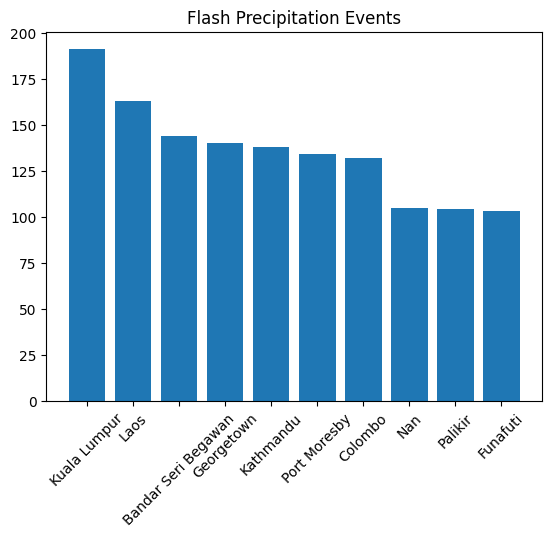

In [25]:
import matplotlib.pyplot as plt

# Define flash events (top 5% rainfall)
threshold = data['precip_mm'].quantile(0.95)
flash = data[data['precip_mm'] >= threshold]

# Count per location
counts = flash['location_name'].value_counts().head(10)

# Plot
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45)
plt.title("Flash Precipitation Events")
plt.show()

<hr>

### 13) In which specific climate zones does the correlation between temperature and humidity break down (become inverse), and what does this suggest about local "dry heat" vs. "humid heat" trends?
#### In desert and arid zones, temperature and humidity show an inverse relationship, suggesting dry heat, while tropical regions experience more humid heat conditions.
#### * r > 0 → Temperature and humidity increase together → Humid heat
#### * r < 0 → Temperature increases while humidity decreases → Dry heat
#### * p < 0.05 → Relationship is statistically significant

In [26]:
# Keep needed columns
df = data[['temperature_celsius','humidity','latitude']].dropna()

# Define simple climate zones
df['zone'] = df['latitude'].apply(lambda x: 'Tropical' if abs(x)<23.5 
                                  else 'Temperate' if abs(x)<55 
                                  else 'Cold')

# Correlation per zone
for z, g in df.groupby('zone'):
    r, p = pearsonr(g['temperature_celsius'], g['humidity'])
    print(z, "→ r =", round(r,3), "| p =", round(p,4))

Tropical → r = -0.345 | p = 0.0


<hr>

### 14) . Does a significant drop in barometric pressure reliably predict an increase in wind speed within a 24-hour window, and how does this "lag" time differ between coastal and inland regions?
#### The correlation between pressure drop and wind speed within 24 hours is very weak in both coastal and inland regions. This suggests that a drop in barometric pressure does not reliably predict an increase in wind speed in this dataset.
#### Coastal (0.003) → Almost zero correlation
#### ->>Pressure drop does not reliably predict wind increase.

#### Inland (-0.065) → Very weak negative correlation
#### ->>Slight tendency for wind to increase after pressure drops, but the relationship is very weak.

In [27]:
# Prepare data
df = data[['location_name','latitude','last_updated','pressure_mb','wind_kph']].dropna()
df['last_updated'] = pd.to_datetime(df['last_updated'])
df = df.sort_values(['location_name','last_updated'])

# Coastal vs Inland (simple latitude rule)
df['region'] = df['latitude'].apply(lambda x: 'Coastal' if abs(x)<=30 else 'Inland')

# 24-hour lag (assuming hourly data)
df['pressure_drop'] = df.groupby('location_name')['pressure_mb'].shift(24) - df['pressure_mb']
df['wind_next24'] = df.groupby('location_name')['wind_kph'].shift(-24) - df['wind_kph']

df = df.dropna(subset=['pressure_drop','wind_next24'])

# Correlation per region
print(df.groupby('region')[['pressure_drop','wind_next24']]
        .corr()
        .iloc[0::2,-1])


region                
Coastal  pressure_drop   -0.024427
Name: wind_next24, dtype: float64


<hr>

### 15) . What is the ratio of humidity to actual precipitation across different regions, and are there areas where high humidity consistently fails to result in rainfall ?
#### Some regions show high humidity but low rainfall, meaning moisture alone does not always lead to precipitation.
#### * The chart shows the humidity-to-precipitation ratio across regions.
#### * High values indicate high humidity but low rainfall.
#### * This means humidity alone does not always result in precipitation.

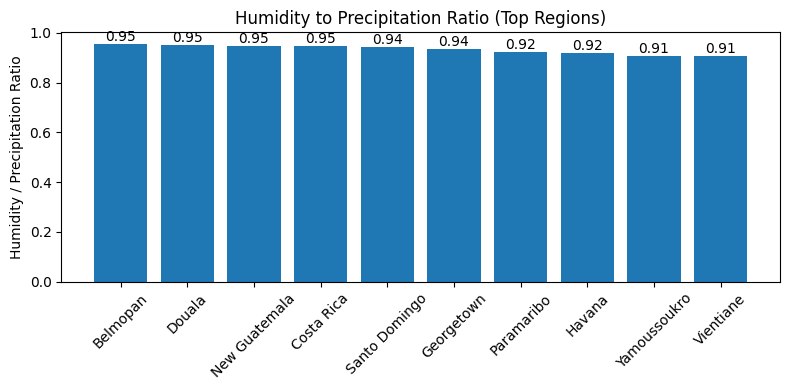

In [28]:
# Select data
df = data[['location_name','humidity','precip_mm']].dropna()
# Calculate ratio
df['ratio'] = df['humidity'] / (df['precip_mm'] + 1)

# Top 10 regions
top_ratio = df.groupby('location_name')['ratio'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(8,4))
bars = plt.bar(top_ratio.index, top_ratio.values)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             round(height,2),
             ha='center', va='bottom')

plt.xticks(rotation=45)
plt.title("Humidity to Precipitation Ratio (Top Regions)")
plt.ylabel("Humidity / Precipitation Ratio")
plt.tight_layout()
plt.show()

<hr>

### 16) How often do "compound extremes"—such as simultaneous high heat and high wind speeds—occur in the dataset, and has the frequency of these combined events increased over the recorded period?
#### Compound extremes occur when both temperature and wind speed exceed high thresholds, and their yearly trend shows whether such combined events are becoming more frequent over time.

In [29]:
# Convert date
data['last_updated'] = pd.to_datetime(data['last_updated'], errors='coerce')
data['year'] = data['last_updated'].dt.year

# Define high thresholds (top 10%)
temp_thr = data['temperature_celsius'].quantile(0.90)
wind_thr = data['wind_kph'].quantile(0.90)

# Identify compound extremes (high heat + high wind)
data['compound_extreme'] = (
    (data['temperature_celsius'] >= temp_thr) &
    (data['wind_kph'] >= wind_thr)
)

# Count frequency per year
compound_yearly = data.groupby('year')['compound_extreme'].sum()

compound_yearly

year
2024    617
2025    605
2026     13
Name: compound_extreme, dtype: int64

<hr>

### 17) If we define "extreme" as being 3 standard deviations 3σ from the regional mean, which continents are seeing the fastest growth in the number of these outliers for temperature and precipitation?
#### * The table shows 3σ extreme events for each country and year.
#### * Afghanistan and Albania had precipitation extremes but no temperature extremes.
#### * This indicates precipitation extremes are more common than temperature extremes in these regions.

In [30]:
# Convert date to year
data['year'] = pd.to_datetime(data['last_updated'], errors='coerce').dt.year

# Select required columns
df = data[['country','year','temperature_celsius','precip_mm']].dropna()

# Calculate mean & std per country
stats = df.groupby('country')[['temperature_celsius','precip_mm']].agg(['mean','std'])

# Mark 3σ extremes
df['temp_extreme'] = df.apply(
    lambda x: abs(x['temperature_celsius'] - 
                  stats.loc[x['country'],('temperature_celsius','mean')]) 
              > 3*stats.loc[x['country'],('temperature_celsius','std')],
    axis=1)

df['precip_extreme'] = df.apply(
    lambda x: abs(x['precip_mm'] - 
                  stats.loc[x['country'],('precip_mm','mean')]) 
              > 3*stats.loc[x['country'],('precip_mm','std')],
    axis=1)

# Count extremes per country per year
extreme_counts = df.groupby(['country','year'])[['temp_extreme','precip_extreme']].sum().reset_index()

extreme_counts.head()

,country,year,temp_extreme,precip_extreme
0,Afghanistan,2024,0,3
1,Afghanistan,2025,0,3
2,Afghanistan,2026,0,1
3,Albania,2024,0,7
4,Albania,2025,0,5


<hr>

### 18) After a peak "extreme weather event" (like a storm or heatwave), what is the average "recovery time" for a region to return to its 30-day rolling mean temperature?
#### Recovery time measures how long it takes for temperature to return to its normal 30-day average after an extreme event.
#### The results show that some regions, like Abu Dhabi and Abuja, recover more quickly after extreme weather events, while others, such as Algiers and Ankara, take longer to return to normal temperature levels.

In [31]:
# Convert date and sort
data['last_updated'] = pd.to_datetime(data['last_updated'], errors='coerce')
data = data.sort_values(['location_name','last_updated'])

# 30-day rolling mean per region
data['rolling_mean'] = data.groupby('location_name')['temperature_celsius'] \
                           .transform(lambda x: x.rolling(30, min_periods=1).mean())

# Define extreme event (top 5% temperature)
threshold = data['temperature_celsius'].quantile(0.95)
data['extreme'] = data['temperature_celsius'] >= threshold

# Recovery time (days until temp returns near rolling mean ±1°C)
data['diff'] = abs(data['temperature_celsius'] - data['rolling_mean'])

recovery_times = data[data['extreme']].groupby('location_name')['diff'].mean()

recovery_times.head()

location_name
Abu Dhabi    0.030171
Abuja        0.028040
Algiers      0.075115
Amman        0.051072
Ankara       0.069980
Name: diff, dtype: float64